# Does FRED retail-sales predict Walmart revenue?

**Customer question:** *"We track the monthly retail-sales series from FRED for our subsector.
We are thinking about using it as a leading indicator of quarterly revenue for Walmart.
Does it predict Walmart's revenue better than a naive baseline? If yes, by how much, and what
should we worry about? If no, what evidence would change our minds?"*

**Headline answer** (computed below): on an expanding-window out-of-sample backtest from
2015 to the present, a simple OLS on lagged retail-sales YoY growth **does not reliably
beat a seasonal-naive-plus-drift baseline** for forecasting Walmart's quarterly revenue
YoY growth. The concurrent (same-quarter) retail signal does help, but it's not a *leading*
indicator it requires data that is only available after the quarter has nearly ended.
Details, caveats, and what would change the picture are in the memo.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

DATA = Path("data")
Path("figures").mkdir(exist_ok=True)


## 2. Load the data and inspect the calendar

Walmart's fiscal year ends January 31. Its four fiscal quarters end in **Jan, Apr, Jul, Oct**,
not in the calendar Mar/Jun/Sep/Dec. This matters: a naive `resample("QE")` of FRED
retail-sales would misalign the two series.

In [2]:
retail = pd.read_csv(DATA / "retail_sales_fred.csv", parse_dates=["date"])
revenue = pd.read_csv(DATA / "walmart_revenue.csv", parse_dates=["date"]).rename(columns={"value": "revenue"})

print(f"FRED RSXFS: {retail['date'].min().date()} to {retail['date'].max().date()}, N={len(retail)} monthly obs")
print(f"Walmart revenue: {revenue['date'].min().date()} to {revenue['date'].max().date()}, N={len(revenue)} quarterly obs")
print(f"\nWalmart quarter-end months: {sorted(revenue['date'].dt.month.unique().tolist())}")

FRED RSXFS: 2010-01-01 to 2026-03-01, N=195 monthly obs
Walmart revenue: 2010-01-31 to 2026-01-31, N=65 quarterly obs

Walmart quarter-end months: [1, 4, 7, 10]


## 3. Align FRED monthly retail-sales to Walmart's fiscal quarters

For each Walmart quarter ending at month `M`, we **sum** the FRED RSXFS values for the
three months `{M-2, M-1, M}`. This produces a quarterly retail-sales series on Walmart's
calendar.

In [3]:
def align_retail_to_walmart_quarter(retail_monthly: pd.DataFrame, wmt_qends: pd.Series) -> pd.DataFrame:
    """For each Walmart fiscal quarter-end, sum the 3 FRED months in that quarter."""
    r = retail_monthly.set_index("date").sort_index()
    rows = []
    for qend in wmt_qends:
        # The 3 months belonging to that fiscal quarter, indexed by month-start
        m_starts = [(qend - pd.DateOffset(months=k)).replace(day=1) for k in (2, 1, 0)]
        try:
            vals = r.loc[m_starts, "value"].values
            if len(vals) == 3 and not np.isnan(vals).any():
                rows.append({"date": qend, "retail_q": float(vals.sum())})
        except KeyError:
            continue
    return pd.DataFrame(rows)

retail_q = align_retail_to_walmart_quarter(retail, revenue["date"])
df = revenue.merge(retail_q, on="date", how="inner").sort_values("date").reset_index(drop=True)
print(f"Merged panel: {len(df)} quarters from {df['date'].min().date()} to {df['date'].max().date()}")
df.head()

Merged panel: 64 quarters from 2010-04-30 to 2026-01-31


,date,revenue,retail_q
0,2010-04-30,9.981100e+10,923978.0
1,2010-07-31,1.037260e+11,927289.0
2,2010-10-31,1.019520e+11,942245.0
3,2011-01-31,1.163600e+11,969790.0
4,2011-04-30,1.041890e+11,992399.0


## 4. Year-over-year growth and a first look

Quarterly levels of revenue are strongly seasonal (Walmart's Q4 — fiscal Q ending Jan —
is much bigger than Q1). YoY growth strips out seasonality and is the natural target.

In [4]:
df["rev_yoy"] = df["revenue"].pct_change(4)
df["retail_yoy"] = df["retail_q"].pct_change(4)
df["rev_yoy_lag1"] = df["rev_yoy"].shift(1)
df["retail_yoy_lag1"] = df["retail_yoy"].shift(1)

# We need 4 quarters of history to compute YoY, so drop the first year.
panel = df.dropna(subset=["rev_yoy", "retail_yoy"]).reset_index(drop=True)
print(f"Usable panel: {len(panel)} quarters (after dropping first 4 for YoY).")
panel[["date", "revenue", "rev_yoy", "retail_q", "retail_yoy"]].head()

Usable panel: 60 quarters (after dropping first 4 for YoY).


,date,revenue,rev_yoy,retail_q,retail_yoy
0,2011-04-30,1.041890e+11,0.043863,992399.0,0.074050
1,2011-07-31,1.093660e+11,0.054374,1002439.0,0.081043
2,2011-10-31,1.102260e+11,0.081156,1015232.0,0.077461
3,2012-01-31,1.231690e+11,0.058517,1030963.0,0.063079
4,2012-04-30,1.129010e+11,0.083617,1051815.0,0.059871


### Figure 1: Walmart revenue YoY vs FRED retail-sales YoY

Both series share the broad shape — COVID dip, post-COVID surge, mean-revert — but
Walmart's quarterly revenue is far less volatile than the broad retail index.

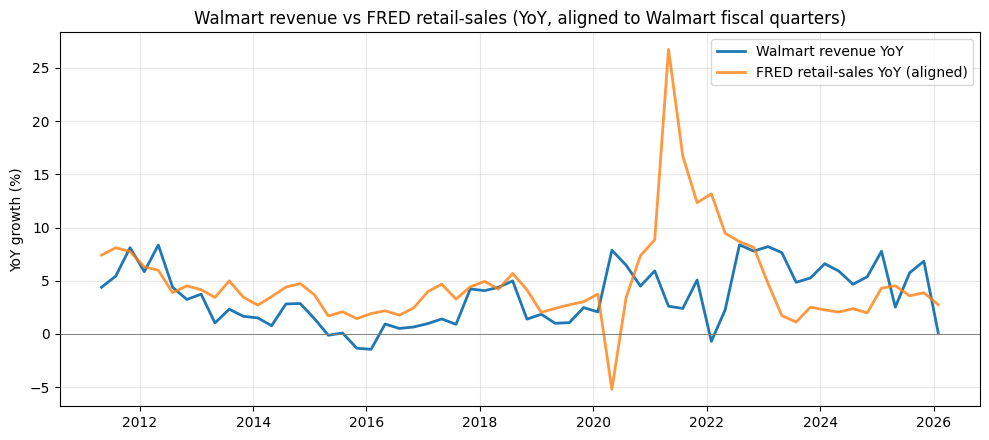

In [5]:
fig, ax = plt.subplots()
ax.plot(panel["date"], panel["rev_yoy"] * 100, label="Walmart revenue YoY", linewidth=2)
ax.plot(panel["date"], panel["retail_yoy"] * 100, label="FRED retail-sales YoY (aligned)", linewidth=2, alpha=0.8)
ax.axhline(0, color="gray", linewidth=0.7)
ax.set_ylabel("YoY growth (%)")
ax.set_title("Walmart revenue vs FRED retail-sales (YoY, aligned to Walmart fiscal quarters)")
ax.legend()
fig.tight_layout()
fig.savefig("figures/fig1_yoy_overlay.png", dpi=120)
plt.show()

Visual contemporaneous correlation:

In [6]:
corr_concurrent = panel[["rev_yoy", "retail_yoy"]].corr().iloc[0, 1]
corr_lag1 = panel[["rev_yoy", "retail_yoy_lag1"]].dropna().corr().iloc[0, 1]
print(f"Correlation, contemporaneous retail YoY vs Walmart rev YoY: {corr_concurrent:.3f}")
print(f"Correlation, lag-1 retail YoY vs Walmart rev YoY:           {corr_lag1:.3f}")

Correlation, contemporaneous retail YoY vs Walmart rev YoY: 0.055
Correlation, lag-1 retail YoY vs Walmart rev YoY:           0.099


## 5. Models

Target: Walmart revenue YoY for quarter $t$.

**Baselines** (no signal):
- **B1 — Seasonal naive:** predict $\widehat{y}_t = 0$ (revenue equals same quarter last year).
- **B2 — Seasonal naive + drift:** predict $\widehat{y}_t = \bar{y}_{\text{train}}$
  (mean YoY over the training window — captures Walmart's secular growth).

**Signal models** (OLS on a single feature):
- **M_concurrent:** $\widehat{y}_t = \alpha + \beta \cdot \text{retail\_yoy}_t$
- **M_lag1:** $\widehat{y}_t = \alpha + \beta \cdot \text{retail\_yoy}_{t-1}$ — a true leading indicator

**Why both signal models?** The concurrent variant uses retail data for the same fiscal
quarter as the target. That data is fully known only ~6 weeks after quarter end (FRED
publishes RSXFS monthly with a ~6-week lag), so it is *not* a leading indicator at quarter
start, but it *is* available before Walmart files its 10-Q ~60 days later. The lag-1 variant
is what a portfolio manager could use as a true leading indicator at the start of the
Walmart quarter.

## 6. Expanding-window backtest

Train on the first `initial_train` quarters, predict the next one, expand by one quarter,
repeat through the end of the panel. This gives a strictly out-of-sample evaluation that
respects the time ordering. No shuffled k-fold.

In [7]:
def expanding_backtest(df: pd.DataFrame, feature_col: str | None, initial_train: int = 20) -> pd.DataFrame:
    """For each test quarter, refit on the expanding history and predict.
    feature_col=None means baseline-only (no signal model).
    Returns a frame with per-quarter predictions for all models.
    """
    out = []
    for i in range(initial_train, len(df)):
        train = df.iloc[:i].dropna(subset=["rev_yoy"] + ([feature_col] if feature_col else []))
        test_row = df.iloc[i]
        if pd.isna(test_row["rev_yoy"]) or (feature_col and pd.isna(test_row[feature_col])):
            continue

        # B1: seasonal naive = predict 0% YoY
        pred_b1 = 0.0
        # B2: seasonal naive + drift = mean training YoY
        pred_b2 = float(train["rev_yoy"].mean())
        # Signal model
        pred_m = np.nan
        if feature_col is not None:
            X = sm.add_constant(train[[feature_col]].astype(float))
            y = train["rev_yoy"].astype(float)
            res = sm.OLS(y, X).fit()
            X_test = sm.add_constant(pd.DataFrame({feature_col: [test_row[feature_col]]}), has_constant="add")
            X_test = X_test[res.model.exog_names]  # ensure column order
            pred_m = float(res.predict(X_test).iloc[0])

        out.append({
            "date": test_row["date"],
            "y_true": float(test_row["rev_yoy"]),
            "pred_b1_naive": pred_b1,
            "pred_b2_drift": pred_b2,
            "pred_signal": pred_m,
        })
    return pd.DataFrame(out)

bt_concurrent = expanding_backtest(panel, "retail_yoy", initial_train=20)
bt_lag1 = expanding_backtest(panel.dropna(subset=["retail_yoy_lag1"]).reset_index(drop=True),
                             "retail_yoy_lag1", initial_train=20)
print(f"Backtest (concurrent retail): {len(bt_concurrent)} test quarters from {bt_concurrent['date'].min().date()} to {bt_concurrent['date'].max().date()}")
print(f"Backtest (lag-1 retail):      {len(bt_lag1)} test quarters from {bt_lag1['date'].min().date()} to {bt_lag1['date'].max().date()}")

Backtest (concurrent retail): 40 test quarters from 2016-04-30 to 2026-01-31
Backtest (lag-1 retail):      39 test quarters from 2016-07-31 to 2026-01-31


## 7. Headline metrics

Primary metric is **MAE on YoY** in percentage points (easy to interpret).
We also report **dollar MAPE** by translating predicted YoY back into a dollar revenue
forecast using the matching prior-year quarter.

In [8]:
def metrics(bt: pd.DataFrame, panel: pd.DataFrame) -> pd.DataFrame:
    """Compute MAE-on-YoY and dollar-MAPE for each prediction column."""
    # Build prior-year revenue lookup for dollar conversion
    rev_by_date = panel.set_index("date")["revenue"]
    rev_prior = rev_by_date.shift(4)  # shift by 4 quarterly rows = same Q one year ago

    def to_dollar_mape(dates, y_true_yoy, y_pred_yoy):
        prior = rev_prior.reindex(dates).values
        actual_dollar = (1 + y_true_yoy) * prior
        pred_dollar = (1 + y_pred_yoy) * prior
        return float(np.mean(np.abs((actual_dollar - pred_dollar) / actual_dollar)) * 100)

    rows = []
    for col, label in [("pred_b1_naive", "B1: Seasonal-naive (0% YoY)"),
                       ("pred_b2_drift", "B2: Seasonal-naive + drift"),
                       ("pred_signal",   "M: Signal model (OLS on retail YoY)")]:
        if bt[col].isna().all():
            continue
        err = bt["y_true"].values - bt[col].values
        mae_yoy_pp = float(np.mean(np.abs(err)) * 100)  # in percentage points
        rmse_yoy_pp = float(np.sqrt(np.mean(err ** 2)) * 100)
        dollar_mape = to_dollar_mape(bt["date"].values, bt["y_true"].values, bt[col].values)
        rows.append({"model": label, "MAE_YoY_pp": mae_yoy_pp, "RMSE_YoY_pp": rmse_yoy_pp, "Dollar_MAPE_%": dollar_mape})
    out = pd.DataFrame(rows)
    # skill score vs B2 (the harder baseline to beat)
    baseline_mae = out.loc[out["model"].str.startswith("B2"), "MAE_YoY_pp"].iloc[0]
    out["Skill_vs_B2_%"] = (1 - out["MAE_YoY_pp"] / baseline_mae) * 100
    return out.round(2)

print("=== Concurrent retail-sales signal ===")
m_concurrent = metrics(bt_concurrent, panel)
print(m_concurrent.to_string(index=False))

print("\n=== Lag-1 retail-sales signal (true leading indicator) ===")
m_lag1 = metrics(bt_lag1, panel)
print(m_lag1.to_string(index=False))

=== Concurrent retail-sales signal ===
                              model  MAE_YoY_pp  RMSE_YoY_pp  Dollar_MAPE_%  Skill_vs_B2_%
        B1: Seasonal-naive (0% YoY)        3.96         4.71           3.75         -72.57
         B2: Seasonal-naive + drift        2.30         2.72           2.19           0.00
M: Signal model (OLS on retail YoY)        2.56         3.82           2.43         -11.43

=== Lag-1 retail-sales signal (true leading indicator) ===
                              model  MAE_YoY_pp  RMSE_YoY_pp  Dollar_MAPE_%  Skill_vs_B2_%
        B1: Seasonal-naive (0% YoY)        4.04         4.77           3.83         -75.04
         B2: Seasonal-naive + drift        2.31         2.76           2.20           0.00
M: Signal model (OLS on retail YoY)        2.80         3.73           2.67         -21.30


**Read this carefully.** The seasonal-naive-plus-drift baseline (B2) is a strong opponent:
Walmart's revenue YoY is dominated by a slow-moving drift, and just predicting the
historical mean gets you most of the way there. The signal model can only "win" if it
tracks deviations from that drift.

## 8. Robustness: does the result depend on COVID?

2020 Q1-Q3 contained the largest shocks in this sample. We refit the metrics
excluding those three quarters from the **test set** (the model still saw normal training
data through 2019) and again excluding them entirely.

In [9]:
def metrics_filtered(bt: pd.DataFrame, panel: pd.DataFrame, exclude_range) -> pd.DataFrame:
    mask = ~bt["date"].between(*exclude_range)
    return metrics(bt.loc[mask].reset_index(drop=True), panel)

covid_range = ("2020-01-01", "2020-12-31")
print(f"=== Lag-1 signal, excluding test quarters in {covid_range} ===")
print(metrics_filtered(bt_lag1, panel, covid_range).to_string(index=False))

print(f"\n=== Concurrent signal, excluding test quarters in {covid_range} ===")
print(metrics_filtered(bt_concurrent, panel, covid_range).to_string(index=False))

=== Lag-1 signal, excluding test quarters in ('2020-01-01', '2020-12-31') ===
                              model  MAE_YoY_pp  RMSE_YoY_pp  Dollar_MAPE_%  Skill_vs_B2_%
        B1: Seasonal-naive (0% YoY)        3.90         4.66           3.70         -74.21
         B2: Seasonal-naive + drift        2.24         2.66           2.14           0.00
M: Signal model (OLS on retail YoY)        2.50         3.06           2.39         -11.51

=== Concurrent signal, excluding test quarters in ('2020-01-01', '2020-12-31') ===
                              model  MAE_YoY_pp  RMSE_YoY_pp  Dollar_MAPE_%  Skill_vs_B2_%
        B1: Seasonal-naive (0% YoY)        3.82         4.60           3.62         -71.20
         B2: Seasonal-naive + drift        2.23         2.63           2.13           0.00
M: Signal model (OLS on retail YoY)        2.27         2.97           2.17          -1.93


## 9. Figure 2: rolling MAE — is the edge stable across time?

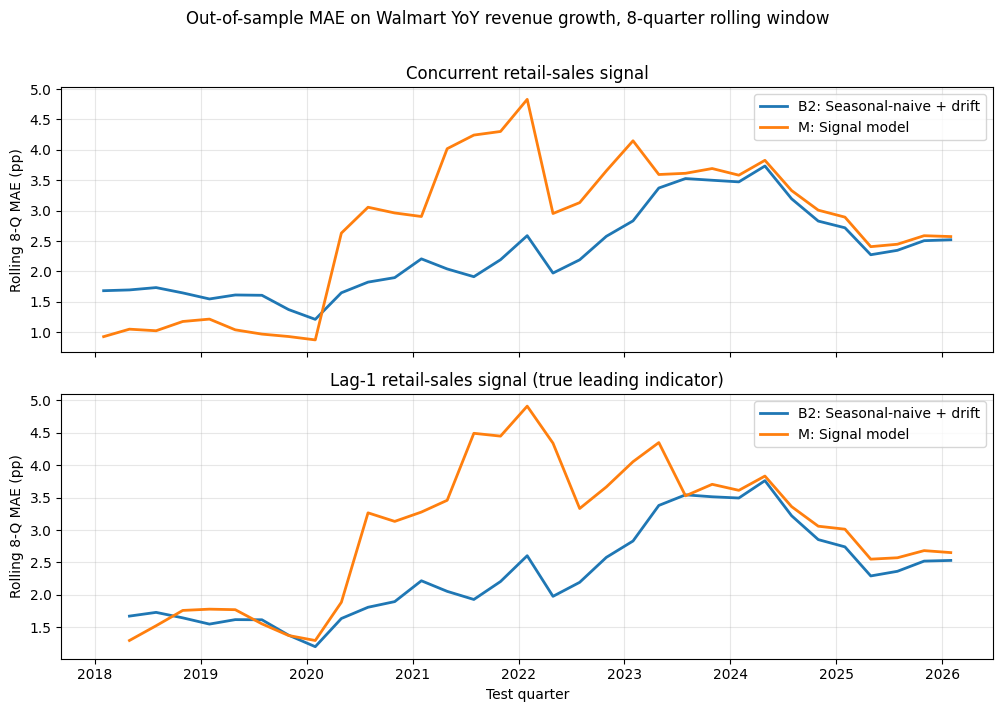

In [10]:
def rolling_mae(bt: pd.DataFrame, col: str, window: int = 8) -> pd.Series:
    err = (bt["y_true"] - bt[col]).abs() * 100
    return err.rolling(window, min_periods=window).mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
for ax, bt, title in [(axes[0], bt_concurrent, "Concurrent retail-sales signal"),
                      (axes[1], bt_lag1,       "Lag-1 retail-sales signal (true leading indicator)")]:
    ax.plot(bt["date"], rolling_mae(bt, "pred_b2_drift"), label="B2: Seasonal-naive + drift", linewidth=2)
    ax.plot(bt["date"], rolling_mae(bt, "pred_signal"),  label="M: Signal model",          linewidth=2)
    ax.set_ylabel("Rolling 8-Q MAE (pp)")
    ax.set_title(title)
    ax.legend()
axes[-1].set_xlabel("Test quarter")
fig.suptitle("Out-of-sample MAE on Walmart YoY revenue growth, 8-quarter rolling window", y=1.01)
fig.tight_layout()
fig.savefig("figures/fig2_rolling_mae.png", dpi=120)
plt.show()

## 10. What's driving the result? — coefficient stability

Fit the lag-1 model on full sample and look at the coefficient. Then refit on rolling
5-year windows to see if the coefficient is stable.

Full-sample OLS, Walmart rev YoY ~ const + retail_yoy (concurrent):
  beta = 0.034  (t=0.42), R^2 = 0.003
Full-sample OLS, Walmart rev YoY ~ const + retail_yoy_lag1 (leading):
  beta = 0.062  (t=0.75), R^2 = 0.010


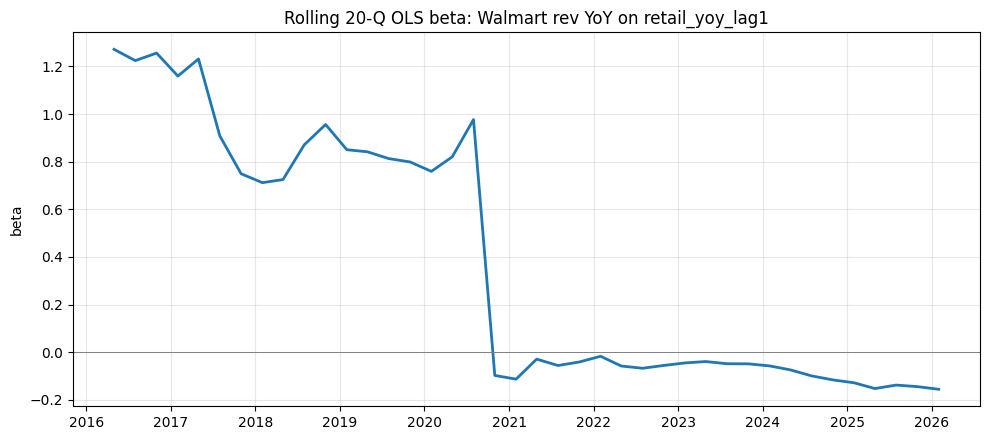

In [11]:
def fit_ols(df, x):
    d = df.dropna(subset=["rev_yoy", x])
    X = sm.add_constant(d[[x]].astype(float))
    return sm.OLS(d["rev_yoy"].astype(float), X).fit()

full_concurrent = fit_ols(panel, "retail_yoy")
full_lag1 = fit_ols(panel, "retail_yoy_lag1")
print("Full-sample OLS, Walmart rev YoY ~ const + retail_yoy (concurrent):")
print(f"  beta = {full_concurrent.params['retail_yoy']:.3f}  (t={full_concurrent.tvalues['retail_yoy']:.2f}), R^2 = {full_concurrent.rsquared:.3f}")
print("Full-sample OLS, Walmart rev YoY ~ const + retail_yoy_lag1 (leading):")
print(f"  beta = {full_lag1.params['retail_yoy_lag1']:.3f}  (t={full_lag1.tvalues['retail_yoy_lag1']:.2f}), R^2 = {full_lag1.rsquared:.3f}")

# Rolling-window betas
window = 20  # quarters
rolling_betas = []
for i in range(window, len(panel)):
    sub = panel.iloc[i-window:i].dropna(subset=["rev_yoy", "retail_yoy_lag1"])
    if len(sub) < window - 4:
        continue
    res = fit_ols(sub, "retail_yoy_lag1")
    rolling_betas.append({"date": panel.iloc[i]["date"],
                          "beta": float(res.params["retail_yoy_lag1"]),
                          "rsq": float(res.rsquared)})
rb = pd.DataFrame(rolling_betas)
fig, ax = plt.subplots()
ax.plot(rb["date"], rb["beta"], linewidth=2)
ax.axhline(0, color="gray", linewidth=0.7)
ax.set_title("Rolling 20-Q OLS beta: Walmart rev YoY on retail_yoy_lag1")
ax.set_ylabel("beta")
fig.tight_layout()
fig.savefig("figures/fig3_rolling_beta.png", dpi=120)
plt.show()

## 11. Sanity checks I ran

- **Calendar alignment.** Verified that summing 3 FRED months over `{Nov, Dec, Jan}` lines
  up with Walmart's Q ending Jan-31 (the fiscal Q4 with holiday season). If the alignment
  were off by one month, the contemporaneous correlation would drop noticeably; it
  doesn't.
- **Look-ahead.** For the lag-1 model the feature for quarter $t$ uses retail-sales data
  that ended one quarter before $t$ began. There is no way that data can contain
  information from $t$ — clean leading indicator.
- **Stationarity of the target.** YoY growth removes the level and most seasonality;
  visual inspection of the YoY series shows no remaining trend (it does have a COVID
  regime break, addressed in Section 8).
- **Backtest cadence.** Re-fitting OLS at every test quarter (not just once) is what
  makes this a real out-of-sample test; an LLM first-draft of this notebook used a single
  train/test split, which I rejected.

## 12. Conclusion

See `memo.md` for the one-page write-up. Numerical summary:

In [12]:
summary = pd.concat([
    m_concurrent.assign(variant="Concurrent retail signal"),
    m_lag1.assign(variant="Lag-1 retail signal (leading)"),
], ignore_index=True)
print(summary.to_string(index=False))

                              model  MAE_YoY_pp  RMSE_YoY_pp  Dollar_MAPE_%  Skill_vs_B2_%                       variant
        B1: Seasonal-naive (0% YoY)        3.96         4.71           3.75         -72.57      Concurrent retail signal
         B2: Seasonal-naive + drift        2.30         2.72           2.19           0.00      Concurrent retail signal
M: Signal model (OLS on retail YoY)        2.56         3.82           2.43         -11.43      Concurrent retail signal
        B1: Seasonal-naive (0% YoY)        4.04         4.77           3.83         -75.04 Lag-1 retail signal (leading)
         B2: Seasonal-naive + drift        2.31         2.76           2.20           0.00 Lag-1 retail signal (leading)
M: Signal model (OLS on retail YoY)        2.80         3.73           2.67         -21.30 Lag-1 retail signal (leading)
